# **Redes Neuronales Convolucionales(CNN): Detección de Objetos**

In [1]:
import io
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torchvision
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from PIL import Image

torch.manual_seed(42)
print("PyTorch:", torch.__version__, " | torchvision:", torchvision.__version__)
dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", dispositivo)

PyTorch: 2.11.0+cpu  | torchvision: 0.26.0+cpu
Dispositivo: cpu


# **Cargar modelo preentrenado**

In [2]:
pesos = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
modelo = fasterrcnn_resnet50_fpn(weights=pesos, box_score_thresh=0.5)
modelo.eval().to(dispositivo)

CLASES_COCO = pesos.meta["categories"]
print(f"Modelo cargado. Puede reconocer {len(CLASES_COCO)} categorías, entre ellas:")
print(CLASES_COCO[1:15], "...")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 151MB/s]


Modelo cargado. Puede reconocer 91 categorías, entre ellas:
['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign', 'parking meter'] ...


# **Cargar una imagen de ejemplo**

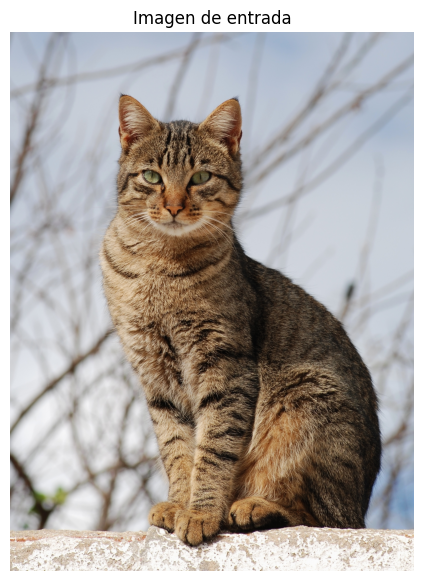

In [4]:
def cargar_imagen(url):
    cabeceras = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    } #Agente para evitar que algunos servidores bloqueen la descarga
    respuesta = requests.get(url, headers=cabeceras, timeout=15)
    return Image.open(io.BytesIO(respuesta.content)).convert("RGB")

# Usamos una URL que apunta directamente a un archivo de imagen (.jpg)
url_imagen = "https://upload.wikimedia.org/wikipedia/commons/4/4d/Cat_November_2010-1a.jpg"
imagen = cargar_imagen(url_imagen)

plt.figure(figsize=(7, 7))
plt.imshow(imagen)
plt.axis("off")
plt.title("Imagen de entrada")
plt.show()

# **Ejecutar la detección**

In [5]:
transformar = transforms.Compose([transforms.ToTensor()])
tensor_imagen = transformar(imagen).to(dispositivo)

with torch.no_grad():
    predicciones = modelo([tensor_imagen])[0]

print("Claves de la predicción:", predicciones.keys())
print(f"Objetos detectados (antes de filtrar por confianza): {len(predicciones['boxes'])}")

Claves de la predicción: dict_keys(['boxes', 'labels', 'scores'])
Objetos detectados (antes de filtrar por confianza): 1


# **Visualizar las cajas delimitadoras**

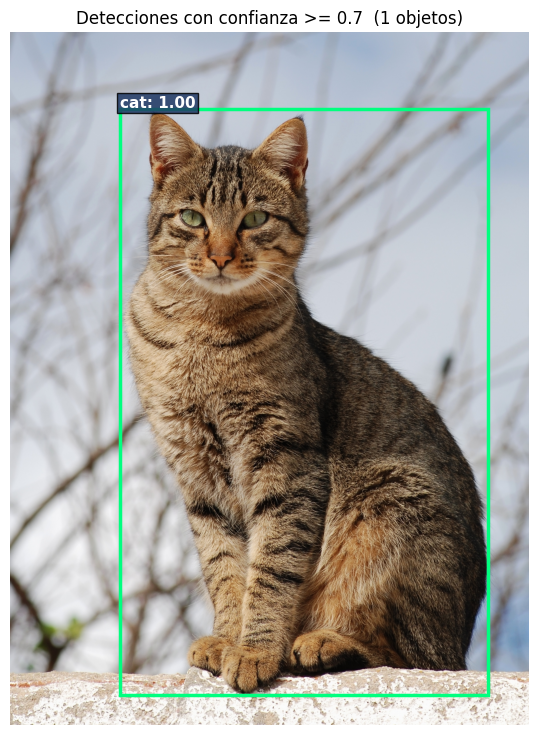

In [6]:
def dibujar_detecciones(imagen, predicciones, umbral=0.7, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(imagen)

    cajas = predicciones["boxes"].cpu().numpy()
    etiquetas = predicciones["labels"].cpu().numpy()
    puntajes = predicciones["scores"].cpu().numpy()

    n_mostradas = 0
    for caja, etiqueta, puntaje in zip(cajas, etiquetas, puntajes):
        if puntaje < umbral:
            continue
        x_min, y_min, x_max, y_max = caja
        rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                  linewidth=2.5, edgecolor="#00FF7F", facecolor="none")
        ax.add_patch(rect)
        nombre_clase = CLASES_COCO[etiqueta]
        ax.text(x_min, y_min - 6, f"{nombre_clase}: {puntaje:.2f}",
                color="white", fontsize=11, weight="bold",
                bbox=dict(facecolor="#1F3864", alpha=0.85, pad=2))
        n_mostradas += 1
    ax.set_title(f"Detecciones con confianza >= {umbral}  ({n_mostradas} objetos)")
    ax.axis("off")
    return n_mostradas

fig, ax = plt.subplots(figsize=(9, 9))
dibujar_detecciones(imagen, predicciones, umbral=0.7, ax=ax)
plt.show()

# **El efecto del umbral de confianza**

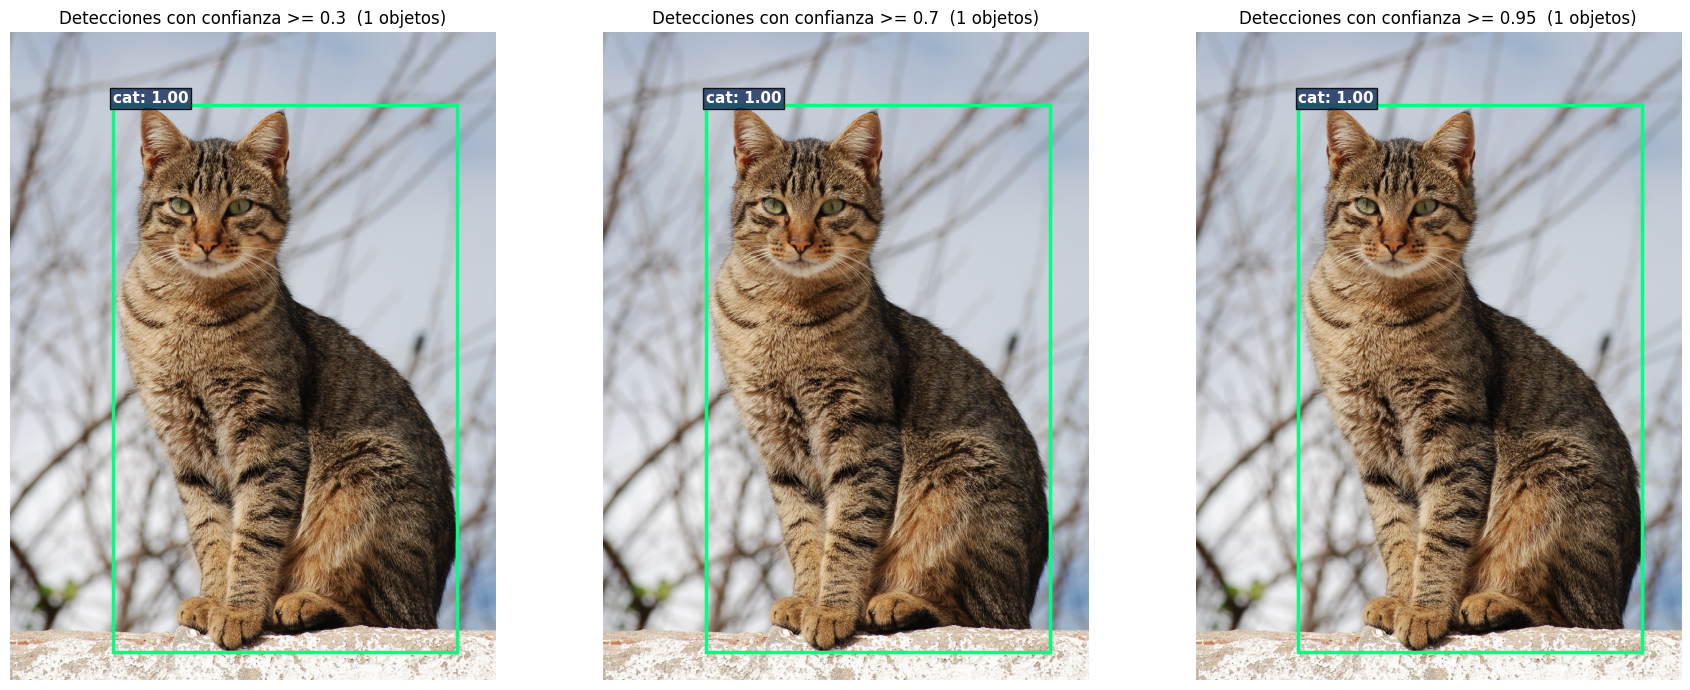

In [7]:
fig, ejes = plt.subplots(1, 3, figsize=(18, 7))
for ax, umbral in zip(ejes, [0.3, 0.7, 0.95]):
    n = dibujar_detecciones(imagen, predicciones, umbral=umbral, ax=ax)
plt.tight_layout()
plt.show()